<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
ترافیک شهری
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    ترافیک شهری به یکی از بزرگترین معظلات شهرنشینان تبدیل شده است. شما هم اگر ساکن شهرهای بزرگی مثل تهران، مشهد و اصفهان باشید، حتما بخش زیادی از وقتتان را در ترافیک گذرانده‌اید.
    <br>
     اما اتلاف وقت، تنها یکی از چندین و چند ضرری است که عدم کنترل و بی‌برنامگی ترافیک به‌بار می‌آورد. افزایش مصرف حامل‌های انرژی، آلودگی هوا و مشکلات  روانی تنها بخشی از آسیب‌های عدم مدیریت ترافیک شهری هستند.
    <br>
    بافت قدیمی شهر‌ها، استاندارد نبودن مسیرها، ضعف سیستم‌های کنترلی مثل چراغ‌های راهنمایی، عدم توازن ناوگان حمل‌ونقل عمومی، از جمله عواملی هستند که روی افزایش ترافیک شهری تاثیر می‌گذارند.
    <br>
    در این تمرین می‌خواهیم به شهرداری کمک کنیم در مدیریت ترافیک شهری، موفق‌تر عمل کند.
    <br>
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    در این تمرین، اطلاعاتی را از ۴ چهار‌راه در کلانشهر اصفهان در اختیار داریم. دوربین‌های سر هر چهارراه، تعداد ماشینی که در هر ساعت شبانه‌روز از چهارراه گذر کرده است را شمرده اند. بنابراین مجموعه داده ما به شکل جدول زیر است.
</font>
</p>


<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|ستون|توضیحات|
|------|---|
|DateTime|زمان ثبت رکورد|
|Junction|شماره چهارراه|
|Car|تعداد ماشین‌های گذرکرده|
    
</font>
</div>



<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
 اطلاعات هر چهارراه از اولین ساعت شبانه‌روز تا ساعت پایانی روز، به مدت چندین ماه، ثبت و ضبط شده است. به عنوان مثال تعداد ماشین‌های گذرکرده از چهارراه اول، از تاریخ 2020/5/2 هر یک ساعت به یک ساعت جمع‌آوری شده است.
    <br>
    هدف این مسئه آن است که تعداد ماشین‌های گذرکننده از هر چهارراه را در هر ساعت از شبانه روز تخمین بزنیم. از آن جایی که شما هنوز با مدلسازی آشنا نیستید، از شما می‌خواهیم در مهندسی ویژگی‌ها به ما کمک کنید. در همین فایل نوت‌بوک سلول‌هایی برای مدلسازی قرار داده شده‌اند که شما نیازی نیست عملکرد آن‌ها را درک کنید، فقط آن‌ها را اجرا کنید و نتیجه پیش‌پردازش‌های خودتان را مشاهده کنید.
    <br>
    حال از شما می‌خواهیم با تکنیک‌هایی که در درسنامه‌های قبلی آموختید، به سنتز و تولید ویژگی بپردازید.
</font>
</p>


<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    ابتدا کتابخانه‌های مورد نیازتان را وارد کنید و سپس مجموعه داده را از فایل بخوانید.
</font>
</p>

In [2]:
%pip install Khayyam

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for Khayyam: filename=khayyam-3.0.17-cp311-cp311-macosx_10_9_universal2.whl size=62222 sha256=dc3958d4e49f4893e9f2ae78345ce47176f4c98e490c7d00167923f8737e13d8
  Stored in directory: /Users/arashdaypir/Library/Caches/pip/wheels/c6/f0/1c/8b75424d3f512690e03427cb09d551bd7e5f17a431316d0da6
Successfully built Khayyam
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd 
from khayyam import JalaliDatetime
from datetime import timedelta

from flaml import AutoML
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('../data/traffic.csv', parse_dates=['DateTime'])

In [3]:
df

,DateTime,Junction,Car
0,2020-05-02 00:00:00,1,25
1,2020-05-02 01:00:00,1,23
2,2020-05-02 02:00:00,1,20
3,2020-05-02 03:00:00,1,12
4,2020-05-02 04:00:00,1,19
...,...,...,...
48115,2021-12-30 19:00:00,4,26
48116,2021-12-30 20:00:00,4,55
48117,2021-12-30 21:00:00,4,31
48118,2021-12-30 22:00:00,4,37



<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    برای آن که ارزش کار خود را درک کنید، نیاز است ابتدا که هیچگونه پیش‌پردازشی روی داده انجام نشده است، یکبار با آن مدلسازی کنید و عملکرد مدل را مشاهده کنید. با اجرای سلول زیر یک مدل روی داده آموزش می‌بیند و نتایجی تولید می‌کند.
    <br>
    اگر اجرای این سلول با شکست مواجه شد، می‌تواند به یکی از دلایل زیر باشد.
</font>
</p>


<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    <ul>
        <li>
            کتابخانه Fast Auto ML را نصب نکرده باشید.
        </li>
        <li>
            در بارگزاری مجموعه داده دچار مشکل شده باشید.
        </li>
    </ul>
</font>
</div>

In [4]:
model = AutoML(task='regression', time_budget=60, verbose=0)
train = df.loc[:48000]
test = df.loc[48000:]
model.fit(train.drop('Car', axis=1), train.Car)
y_pred = model.predict(test.drop('Car', axis=1))
r2score = round(r2_score(test.Car, y_pred),2) * 100 
print(f'performance of model is {r2score}%')

performance of model is 45.0%


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
قسمت اول
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    متاسفانه دوربین‌هایی که در چهارراه‌ها نصب شده بودند، همگی وارداتی بوده اند. بنابراین به جای ثبت تاریخ، طبق تقویم جلالی (هجری شمسی)، تاریخ را به صورت میلادی ذخیره کرده‌است.
    <br>
    در اولین گام، از شما می‌خواهیم با استفاده از 
    <a href="https://khayyam.dobisel.com/">کتابخانه خیام</a>
    که برای کار با تقویم جلالی توسعه یافته‌است، همه تاریخ‌های میلادی را به تاریخ شمسی تبدیل کنید. به عبارت بهتر، معادل شمسی تاریخ‌هایی که در ستون <code>DateTime</code> دیتافریم <code>df</code> وجود دارند را درون ستون <code>JalaliDateTime</code> ذخیره کنید.
    <br>
    توجه داشته باشید، ستون <code>JalaliDateTime</code> در سلول جوابساز، به عنوان یکی از مولفه‌هایی که مورد داوری قرار می‌گیرند، از دیتافریم <code>df</code> استخراج می‌شود. بنابراین هیچ تغییری در ترتیب سطر‌ها و اسم ستون اعمال نکنید.
    <br>
    برای انجام راحت‌تر این قسمت و آشنایی بیشتر با کتابخانه خیام، سلول زیر را اجرا و نتیجه آن را مشاهده کنید.
    <br>
    به نحوه تغییر تاریخ میلادی به تاریخ شمسی توجه کنید!
</font>
</p>

In [4]:
from datetime import datetime as dt
miladi_date = dt(1998,10,29)
print(f'Miladi date = {miladi_date}')

from khayyam import JalaliDatetime
shamsi_date = JalaliDatetime(miladi_date)
print('Sahmsi date = ', shamsi_date)

Miladi date = 1998-10-29 00:00:00
Sahmsi date =  1377-08-07 00:00:00.000000


In [5]:
#TODO: convert gregorian datetime to jalali datatime
df['JalaliDateTime'] = df['DateTime'].apply(lambda x: JalaliDatetime(x))

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
قسمت دوم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    قصد داریم گسسته‌شده ساعتی که یک رکورد ثبت شده است را به عنوان ویژگی جدیدی به دیتافریم <code>df</code> اضافه کنیم. اسم این ستون را <code>hour</code> بگذارید.
    <br>
    به این منظور لازم است طبق جدول زیر، ساعات شبانه روز را گسسته کنیم.
    
</font>
</p>


<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>

|ساعت|دسته متناظر|
|------|------|
|از ۰۰:۰۰ تا ۵:۵۹:۵۹|0|
|از ۶:۰۰ تا ۱۱:۵۹:۵۹|1|
|از ۱۲:۰۰ تا ۱۴:۵۹:۵۹|2|
|از ۱۵:۰۰ تا ۱۷:۵۹:۵۹|3|
|از ۱۸:۰۰ تا ۲۱:۵۹:۵۹|4|
|از ۲۲:۰۰ تا ۲۳:۵۹:۵۹|5|
    
</font>
</div>


<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    بازه‌هایی که در ستون ساعت در جدول بالا آمده است، از هر دو طرف بسته اند. یعنی وقتی می‌گوییم از ساعت ۰۰:۰۰ تا ۵:۵۹:۵۹ را به دسته 0 نگاشت کنید، به این معنی است که هم ساعت ۰۰:۰۰ و هم ساعت ۵:۵۹:۵۹ جز ساعاتی هستند که باید در دسته 0 قرار گیرند.
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    توجه داشته باشید، ستون <code>hour</code> در سلول جوابساز، به عنوان یکی از مولفه‌هایی که مورد داوری قرار می‌گیرند، از دیتافریم <code>df</code> استخراج می‌شود. بنابراین هیچ تغییری در ترتیب سطر‌ها و اسم ستون اعمال نکنید.
 <br>
    دلیل انتخاب این ویژگی آن است که انتظار داریم تعداد ماشین‌هایی که در نیمه‌های شب در چهارراه‌ها تردد می‌کنند با تعداد ماشین‌هایی که از ساعت ۱۸ تا ۲۲ تردد می‌کنند، متفاوت باشد. البته درست آن است که با تحلیل داده و مصورسازی داده، این تفاوت عددی را توجیه کنیم. این کار را به عنوان تمرین بیشتر، به شما می‌سپاریم!
</font>
</p>

In [6]:
#TODO: add hour of record to dateset as a new column named `hour`
def map_time_to_cat(t):
    hour = t.hour
    if 0 <= hour < 6:
        return 0
    elif 6 <= hour < 12:
        return 1
    elif 12 <= hour < 15:
        return 2
    elif 15 <= hour < 18:
        return 3
    elif 18 <= hour < 22:
        return 4
    else:
        return 5

df['hour'] = df['DateTime'].apply(map_time_to_cat)

In [7]:
import matplotlib.pyplot as plt

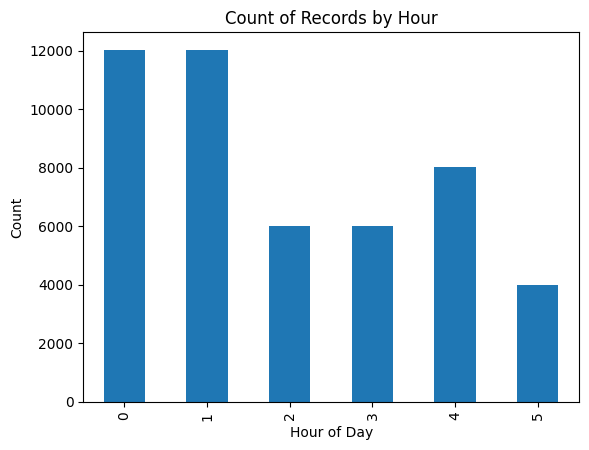

In [8]:
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Count of Records by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
قسمت سوم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    در قسمت سوم از شما می‌خواهیم تعطیل بودن یا نبودن روز ثبت رکورد را تحت ستون جدیدی به اسم <code>IsHoliday</code> به دیتافریم اضافه کنید.
    <br>
    این ستون دارای دو مقدار ۰ و ۱ خواهد بود. در صورتی که روز ثبت رکورد، جمعه بوده باشد، این ستون ۱ و در غیر این صورت مقدار ۰ خواهد داشت.
    <br>
    علت انتخاب این ویژگی آن است که انتظار داریم، میزان تردد چهارراه‌ها در روز‌های تعطیل متفاوت از سایر روزها باشد. زیرا تعداد زیادی از ارگان‌ها مانند بانک‌ها یا مدارس، در روزهای تعطیل فعالیتی ندارند و کارمندی در آن‌ها مشغول به کار نیست. 
</font>
</p>

In [9]:
#TODO: determine whether it is a holiday or not. Add this feature to `df` as a new column named `IsHoliday`
df['IsHoliday'] = df['DateTime'].apply(lambda x: 1 if x.day_name() == 'Friday' else 0)

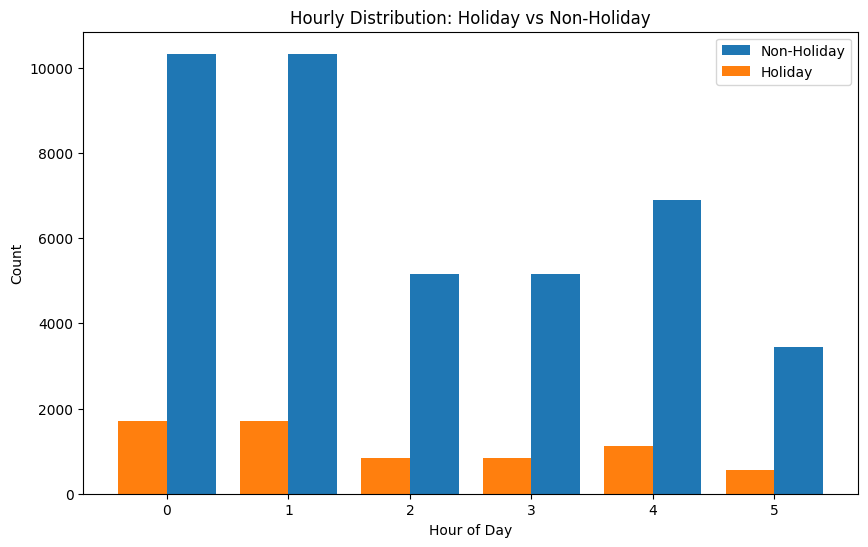

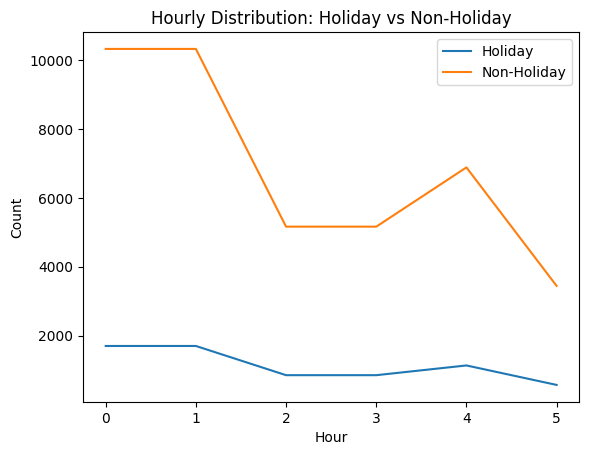

In [10]:
holiday_counts = df[df['IsHoliday']==1]['hour'].value_counts().sort_index()
nonholiday_counts = df[df['IsHoliday']==0]['hour'].value_counts().sort_index()

x = np.arange(len(holiday_counts.index)) # positions for hours
width = 0.4  

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x + width/2, nonholiday_counts.values, width, label='Non-Holiday')
ax.bar(x - width/2, holiday_counts.values, width, label='Holiday')


ax.set_xticks(x)
ax.set_xticklabels(holiday_counts.index)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Count')
ax.set_title('Hourly Distribution: Holiday vs Non-Holiday')
ax.legend()
plt.show()

plt.plot(holiday_counts.index, holiday_counts.values, label='Holiday')
plt.plot(nonholiday_counts.index, nonholiday_counts.values, label='Non-Holiday')
plt.title('Hourly Distribution: Holiday vs Non-Holiday')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.legend()
plt.show()


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
قسمت چهارم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    در قسمت چهارم این سوال می‌خواهیم بدانیم آیا یک رکورد در نیمه سرد سال ثبت شده است یا نیمه گرم سال. منظور از نیمه گرم سال، از شروع فروردین تا انتهای شهریور و منظور از نیمه سرد سال، از ابتدای مهر تا انتهای اسفند است.
    <br>
    اینکه یک رکورد در نیمه سرد سال ثبت شده باشد یا نه را به عنوان ستون جدیدی به اسم <code>IsCold</code> به دیتافریم <code>df</code> اضافه کنید.
    <br>
    این ستون فقط دو مقدار ۰ و ۱ قبول می‌کند. برای نیمه سرد سال عدد ۱ و برای نیمه گرم سال عدد ۰ را لحاظ کنید.
    <br>
    علت انتخاب این ویژگی آن است که در نیمه گرم سال، انتظار داریم مردم بیشتر با موتورسیکلت یا دوچرخه به تردد در شهر بپردازند و در نیمه سرد سال، برای حفاظت از سرما، بیشتر از اتوموبیل استفاده کنند.
</font>
</p>

In [11]:
#TODO: determinte whether it is cold or not. Add this feature to `df` as a new column named `IsCold`
df['IsCold'] = df['JalaliDateTime'].apply(lambda x: 1 if x.month>6 else 0)

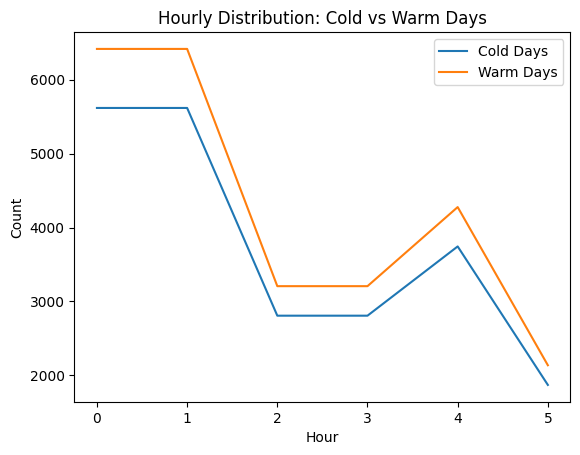

In [12]:
cold_counts = df[df['IsCold']==1]['hour'].value_counts().sort_index()
warm_counts = df[df['IsCold']==0]['hour'].value_counts().sort_index()

plt.plot(cold_counts.index, cold_counts.values, label='Cold Days')
plt.plot(warm_counts.index, warm_counts.values, label='Warm Days')
plt.title('Hourly Distribution: Cold vs Warm Days')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.legend()
plt.show()


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
قسمت پنجم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    می‌دانیم که شماره چهارراه، یک متغیر گسسته اسمی است. بنابراین بهتر است آن را به شکل <code>one-hot-encoded</code> به دیتافریم <code>df</code> اضافه کنیم.
    <br>
    بنابراین با استفاده از ستون <code>Junction</code> چهار ستون با پیشوند <code>Junc</code> بسازید و آن‌ها را به دیتافریم <code>df</code> اضافه کنید.
    برای درک بهتر، تصور کنید این شش سطر زیر، بخشی از دیتافریم <code>df</code> باشند.
</font>
</p>


<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|Junction|
|-------|
|1|
|2|
|3|
|4|
|2|
|1|
    
</font>
</div>


<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    انتظار داریم پس از انجام <code>one-hot-encode</code> چهار ستون مانند جدول زیر به ازای این ۶ سطر به دیتافریم <code>df</code> اضافه شوند.
</font>
</p>



<div style="line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|Junc_1|Junc_2|Junc_3|Junc_4|
|-------|-------|-------|-------|
|1|0|0|0|
|0|1|0|0|
|0|0|1|0|
|0|0|0|1|
|0|1|0|0|
|1|0|0|0|
    
</font>
</div>

In [13]:
#TODO: one-hot-encode the `Jucntion` column and add 4 columns to `df` with `Junc` prefix 
df = pd.concat([df,pd.get_dummies(df['Junction'],prefix='Junc')],axis=1)

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>


In [14]:
import zipfile
import joblib

synthesized_cols = ['JalaliDateTime', 'hour', 'IsHoliday', 'IsCold', 'Junc_1', 'Junc_2', 'Junc_3', 'Junc_4']

submision_df = df[synthesized_cols]

submision_df.to_csv('df.csv', index=False)


def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["df.csv", "traffic_shahri.ipynb"]
compress(file_names)

File Paths:
['df.csv', 'traffic_shahri.ipynb']



<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    پس از اجرای سلول بالا، می‌توانید برای کسب نمره، فایل results.zip را برای سامانه داوری ارسال کنید.
    <br>
    اگر تمایل به مشاهده تاثیر پیش‌پردازش‌های انجام‌شده دارید، سلول‌های زیر را اجرا کنید.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مدلسازی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    حال که سوالات را حل کردید، پیشنهاد می‌کنیم مجددا روی مجموعه‌داده جدیدی که به دست آوردید، مدلسازی کنید تا تاثیر پیش‌پردازش را در نتیجه نهایی مشاهده کنید.
</font>
</p>


<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    برای انجام مدلسازی دوباره، فقط کافیست سلول زیر را اجرا کنید.
    <br>
    اگر اجرای این سلول با شکست مواجه شد، می‌تواند به یکی از دلایل زیر باشد.
</font>
</p>


<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    <ul>
        <li>
            کتابخانه Fast Auto ML را نصب نکرده باشید.
        </li>
        <li>
           پیش‌پردازش‌های توضیح داده‌شده را اشتباه انجام داده باشید.
        </li>
    </ul>
</font>
</div>

In [15]:
model = AutoML(task='regression', time_budget=60, verbose=0)
useful_cols = ['DateTime', 'hour', 'IsHoliday', 'IsCold', 'Junc_1', 'Junc_2', 'Junc_3', 'Junc_4', 'Car']
train = df[useful_cols].loc[:48000]
test = df[useful_cols].loc[48000:]
model.fit(train.drop('Car', axis=1), np.log(train.Car))
y_pred = np.exp(model.predict(test.drop('Car', axis=1)))
r2score = round(r2_score(test.Car, y_pred),2) * 100 
print(f'performance of model is {r2score}%')

performance of model is 60.0%
